In [2]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict,Literal

In [4]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    
    equation: str
    discriminant: float
    result: str

In [9]:
def show_equation(state: QuadState):
    
    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
    
    return {'equation':equation}

def calculate_discriminent(state:QuadState):
    discriminent = state['b']**2 - (4*state["a"]*state['c'])
    
    return {'discriminant':discriminent}

def real_roots(state:QuadState):
    root1 = (-state['b']+state['discriminant']**0.5)/(2*state['a'])
    root2 = (-state['b']-state['discriminant']**0.5)/(2*state['a'])
    
    result = f'The roots are {root1} and {root2}'
    
    return {'result': result}

def repeated_roots(state:QuadState):
    root1 = (-state['b'])/(2*state['a'])
    
    
    result = f'Only repeating root is {root1} '
    
    return {'result': result}

def no_real_roots(state:QuadState):
    
    result = f'No real roots'
    
    return {'result': result}
    


In [10]:
def check_condition(state:QuadState) -> Literal['real_roots','repeated_roots','no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else :
        return 'no_real_roots'

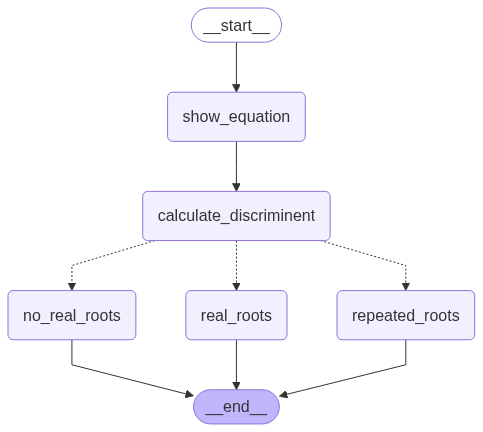

In [11]:
graph = StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminent',calculate_discriminent)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminent')
graph.add_conditional_edges('calculate_discriminent',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)

workflow = graph.compile()
workflow


In [16]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}
workflow.invoke(initial_state)['result']

'The roots are 1.8042476415070754 and -0.5542476415070754'